In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [462]:
import numpy as np
from stable_baselines3.common.env_checker import check_env

# Sequential DDA environment test

In [4]:
from vimms.Common import POSITIVE
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.features import obs_to_dfs

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
 /opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning:hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.


In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (500, 2000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E5, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE
noise_density = 0.3
noise_max_val = 1e4

In [9]:
mzml_filename = 'Beer_multibeers_1_fullscan1.mzML'
mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                       min_log_intensity=min_log_intensity,
                                       max_log_intensity=max_log_intensity)

2022-03-16 11:05:21.022 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 1109 scans
2022-03-16 11:05:22.933 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 1109 scans


In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
    },
    'noise': {
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'N': N,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
        'min_ms1_intensity': min_ms1_intensity
    }
}

Initialise a new DDA environment that tracks the top-20 most intense peaks.

In [463]:
max_peaks = 10
env = DDAEnv(max_peaks, params)
check_env(env)

Generate an initial observation (MS1 scan) -- can be empty

In [464]:
observation = env.reset()
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

(   intensities  fragmented  excluded  above_min_intensity
 0          0.0         0.0       0.0                  0.0
 1          0.0         0.0       0.0                  0.0
 2          0.0         0.0       0.0                  0.0
 3          0.0         0.0       0.0                  0.0
 4          0.0         0.0       0.0                  0.0
 5          0.0         0.0       0.0                  0.0
 6          0.0         0.0       0.0                  0.0
 7          0.0         0.0       0.0                  0.0
 8          0.0         0.0       0.0                  0.0
 9          0.0         0.0       0.0                  0.0,
                               counts
 ms_level                         1.0
 fragmented_above                 0.0
 fragmented_below                 0.0
 unfragmented_above               0.0
 unfragmented_below              10.0
 excluded_above                   0.0
 excluded_below                   0.0
 fragmented_excluded_above        0.0
 fragmen

In [465]:
observation['valid_actions']

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [466]:
env.features

[]

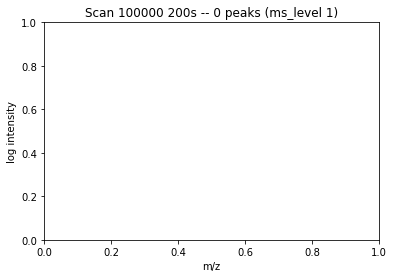

In [467]:
env.render()

Generate 5 ms1 scans

In [468]:
for i in range(5):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward -0.1
done False


(   intensities  fragmented  excluded  above_min_intensity
 0     1.000000         0.0       0.0                  1.0
 1     0.087731         0.0       0.0                  1.0
 2     0.034319         0.0       0.0                  1.0
 3     0.033857         0.0       0.0                  1.0
 4     0.002892         0.0       0.0                  1.0
 5     0.002228         0.0       0.0                  1.0
 6     0.000023         0.0       0.0                  1.0
 7     0.000000         0.0       0.0                  0.0
 8     0.000000         0.0       0.0                  0.0
 9     0.000000         0.0       0.0                  0.0,
                               counts
 ms_level                         1.0
 fragmented_above                 0.0
 fragmented_below                 0.0
 unfragmented_above               7.0
 unfragmented_below               3.0
 excluded_above                   0.0
 excluded_below                   0.0
 fragmented_excluded_above        0.0
 fragmen

In [469]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.])

In [470]:
env.features

[mz=116.48078895423322 rt=202.00000000000003 intensity=396051376.34307563 (1.0),
 mz=104.2181996640492 rt=202.00000000000003 intensity=34745882.78126777 (0.08773074620291052),
 mz=120.20752862657734 rt=202.00000000000003 intensity=13592282.923601927 (0.034319494225990885),
 mz=438.32331220345816 rt=202.00000000000003 intensity=13408937.205475166 (0.0338565600485625),
 mz=216.02043018649454 rt=202.00000000000003 intensity=1145274.9268332268 (0.002891733232713585),
 mz=118.24477931183603 rt=202.00000000000003 intensity=882337.4417759918 (0.002227835817471508),
 mz=193.33633243447903 rt=202.00000000000003 intensity=8958.428013266435 (2.2619358367047522e-05)]

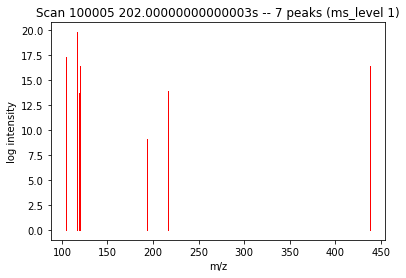

In [471]:
env.render()

Target the most intense precursor for fragmentation, and generate an MS2 scan from that

In [472]:
action = 0
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward 0.7487365832338015
done False


(   intensities  fragmented  excluded  above_min_intensity
 0     1.000000         1.0       1.0                  1.0
 1     0.087731         0.0       0.0                  1.0
 2     0.034319         0.0       0.0                  1.0
 3     0.033857         0.0       0.0                  1.0
 4     0.002892         0.0       0.0                  1.0
 5     0.002228         0.0       0.0                  1.0
 6     0.000023         0.0       0.0                  1.0
 7     0.000000         0.0       0.0                  0.0
 8     0.000000         0.0       0.0                  0.0
 9     0.000000         0.0       0.0                  0.0,
                               counts
 ms_level                         2.0
 fragmented_above                 1.0
 fragmented_below                 0.0
 unfragmented_above               6.0
 unfragmented_below               3.0
 excluded_above                   1.0
 excluded_below                   0.0
 fragmented_excluded_above        1.0
 fragmen

In [473]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.])

In [474]:
env.features

[mz=116.48078895423322 rt=202.00000000000003 intensity=396051376.34307563 (1.0),
 mz=104.2181996640492 rt=202.00000000000003 intensity=34745882.78126777 (0.08773074620291052),
 mz=120.20752862657734 rt=202.00000000000003 intensity=13592282.923601927 (0.034319494225990885),
 mz=438.32331220345816 rt=202.00000000000003 intensity=13408937.205475166 (0.0338565600485625),
 mz=216.02043018649454 rt=202.00000000000003 intensity=1145274.9268332268 (0.002891733232713585),
 mz=118.24477931183603 rt=202.00000000000003 intensity=882337.4417759918 (0.002227835817471508),
 mz=193.33633243447903 rt=202.00000000000003 intensity=8958.428013266435 (2.2619358367047522e-05)]

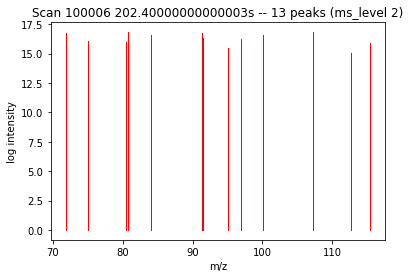

In [475]:
env.render()

Target the next most intense precursor for fragmentation, and generate an MS2 scan

In [476]:
action = 1
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward 0.678013016965852
done False


(   intensities  fragmented  excluded  above_min_intensity
 0     1.000000         1.0       1.0                  1.0
 1     0.087731         1.0       1.0                  1.0
 2     0.034319         0.0       0.0                  1.0
 3     0.033857         0.0       0.0                  1.0
 4     0.002892         0.0       0.0                  1.0
 5     0.002228         0.0       0.0                  1.0
 6     0.000023         0.0       0.0                  1.0
 7     0.000000         0.0       0.0                  0.0
 8     0.000000         0.0       0.0                  0.0
 9     0.000000         0.0       0.0                  0.0,
                               counts
 ms_level                         2.0
 fragmented_above                 2.0
 fragmented_below                 0.0
 unfragmented_above               5.0
 unfragmented_below               3.0
 excluded_above                   2.0
 excluded_below                   0.0
 fragmented_excluded_above        2.0
 fragmen

In [477]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.])

In [478]:
env.features

[mz=116.48078895423322 rt=202.00000000000003 intensity=396051376.34307563 (1.0),
 mz=104.2181996640492 rt=202.00000000000003 intensity=34745882.78126777 (0.08773074620291052),
 mz=120.20752862657734 rt=202.00000000000003 intensity=13592282.923601927 (0.034319494225990885),
 mz=438.32331220345816 rt=202.00000000000003 intensity=13408937.205475166 (0.0338565600485625),
 mz=216.02043018649454 rt=202.00000000000003 intensity=1145274.9268332268 (0.002891733232713585),
 mz=118.24477931183603 rt=202.00000000000003 intensity=882337.4417759918 (0.002227835817471508),
 mz=193.33633243447903 rt=202.00000000000003 intensity=8958.428013266435 (2.2619358367047522e-05)]

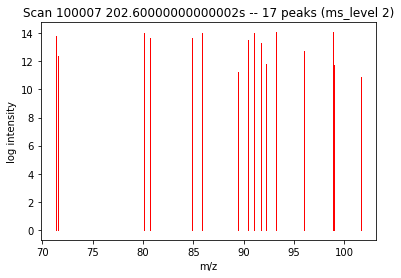

In [479]:
env.render()

Repeat targeting of the same precursor produces negative reward, up to a point

In [480]:
for i in range(10):
    action = 0
    observation, reward, done, info = env.step(action)
    print('reward', reward)
    # print('done', done)
    # pp.pprint(observation)
    # env.render()

reward -0.3333333333333333
reward -0.3333333333333333
reward -0.3333333333333333
reward -0.3333333333333333
reward -0.3333333333333333
reward -0.3333333333333333
reward -0.3333333333333333
reward -0.3333333333333333
reward -0.3333333333333333
reward -0.3333333333333333


In [481]:
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

(   intensities  fragmented  excluded  above_min_intensity
 0     1.000000        11.0       1.0                  1.0
 1     0.087731         1.0       1.0                  1.0
 2     0.034319         0.0       0.0                  1.0
 3     0.033857         0.0       0.0                  1.0
 4     0.002892         0.0       0.0                  1.0
 5     0.002228         0.0       0.0                  1.0
 6     0.000023         0.0       0.0                  1.0
 7     0.000000         0.0       0.0                  0.0
 8     0.000000         0.0       0.0                  0.0
 9     0.000000         0.0       0.0                  0.0,
                               counts
 ms_level                         2.0
 fragmented_above                 1.0
 fragmented_below                 0.0
 unfragmented_above               5.0
 unfragmented_below               3.0
 excluded_above                   2.0
 excluded_below                   0.0
 fragmented_excluded_above        1.0
 fragmen

In [482]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.])

In [483]:
env.features

[mz=116.48078895423322 rt=202.00000000000003 intensity=396051376.34307563 (1.0),
 mz=104.2181996640492 rt=202.00000000000003 intensity=34745882.78126777 (0.08773074620291052),
 mz=120.20752862657734 rt=202.00000000000003 intensity=13592282.923601927 (0.034319494225990885),
 mz=438.32331220345816 rt=202.00000000000003 intensity=13408937.205475166 (0.0338565600485625),
 mz=216.02043018649454 rt=202.00000000000003 intensity=1145274.9268332268 (0.002891733232713585),
 mz=118.24477931183603 rt=202.00000000000003 intensity=882337.4417759918 (0.002227835817471508),
 mz=193.33633243447903 rt=202.00000000000003 intensity=8958.428013266435 (2.2619358367047522e-05)]

Making an invalid move produces negative reward.

In [484]:
action = 9 # no precursor to fragment at this index
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward -1
done False


(   intensities  fragmented  excluded  above_min_intensity
 0     1.000000        11.0       1.0                  1.0
 1     0.087731         1.0       1.0                  1.0
 2     0.034319         0.0       0.0                  1.0
 3     0.033857         0.0       0.0                  1.0
 4     0.002892         0.0       0.0                  1.0
 5     0.002228         0.0       0.0                  1.0
 6     0.000023         0.0       0.0                  1.0
 7     0.000000         0.0       0.0                  0.0
 8     0.000000         0.0       0.0                  0.0
 9     0.000000         1.0       1.0                  0.0,
                               counts
 ms_level                         2.0
 fragmented_above                 1.0
 fragmented_below                 1.0
 unfragmented_above               5.0
 unfragmented_below               2.0
 excluded_above                   2.0
 excluded_below                   1.0
 fragmented_excluded_above        1.0
 fragmen

In [485]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1.])

In [486]:
env.features

[mz=116.48078895423322 rt=202.00000000000003 intensity=396051376.34307563 (1.0),
 mz=104.2181996640492 rt=202.00000000000003 intensity=34745882.78126777 (0.08773074620291052),
 mz=120.20752862657734 rt=202.00000000000003 intensity=13592282.923601927 (0.034319494225990885),
 mz=438.32331220345816 rt=202.00000000000003 intensity=13408937.205475166 (0.0338565600485625),
 mz=216.02043018649454 rt=202.00000000000003 intensity=1145274.9268332268 (0.002891733232713585),
 mz=118.24477931183603 rt=202.00000000000003 intensity=882337.4417759918 (0.002227835817471508),
 mz=193.33633243447903 rt=202.00000000000003 intensity=8958.428013266435 (2.2619358367047522e-05)]

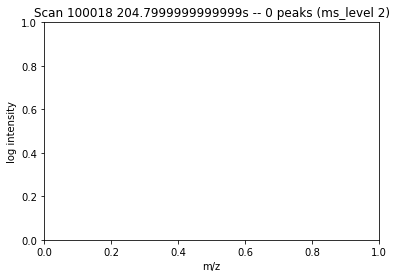

In [487]:
env.render()

Generate another MS1 scan

In [488]:
action = max_peaks # ms1
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward 0.8
done False


(   intensities  fragmented  excluded  above_min_intensity
 0     1.000000         0.0       1.0                  1.0
 1     0.085166         0.0       1.0                  1.0
 2     0.033612         0.0       0.0                  1.0
 3     0.032995         0.0       0.0                  1.0
 4     0.032070         0.0       0.0                  1.0
 5     0.002970         0.0       0.0                  1.0
 6     0.002936         0.0       0.0                  1.0
 7     0.002524         0.0       0.0                  1.0
 8     0.002256         0.0       0.0                  1.0
 9     0.000977         0.0       0.0                  1.0,
                               counts
 ms_level                         1.0
 fragmented_above                 0.0
 fragmented_below                 0.0
 unfragmented_above              10.0
 unfragmented_below               0.0
 excluded_above                   2.0
 excluded_below                   0.0
 fragmented_excluded_above        0.0
 fragmen

In [458]:
observation['valid_actions']

array([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [459]:
env.features

[mz=104.84154291435203 rt=204.9999999999999 intensity=43160.302529152774 (1.0),
 mz=276.0775403171941 rt=204.9999999999999 intensity=16677.394228175 (0.3864058695350941)]

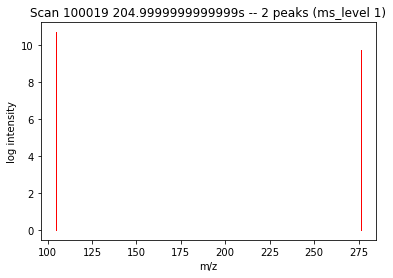

In [460]:
env.render()